In [2]:
# %pip install numpy==1.26.4
# %pip install catboost
from catboost import CatBoostRegressor

In [3]:
import pandas as pd

In [6]:
# %pip install scikit-learn
from sklearn.model_selection import train_test_split

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [8]:
df = pd.read_csv("df_merged_cleaned_high_corr.csv")

In [9]:
df['Date'] = pd.to_datetime(df['Date'])
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['week'] = df['Date'].dt.isocalendar().week

In [46]:
X = df.drop(columns=['Цена на арматуру'])
y = df['Цена на арматуру']

In [11]:
# Разделение на обучающие и тестовые наборы
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [12]:
# Обучение модели CatBoost
model = CatBoostRegressor(iterations=10000, learning_rate=0.03, depth=6, loss_function='MAE', verbose=1, early_stopping_rounds=100)
model.fit(X_train, y_train)

0:	learn: 6536.2046813	total: 135ms	remaining: 22m 25s
1:	learn: 6364.4875651	total: 137ms	remaining: 11m 23s
2:	learn: 6210.2391339	total: 139ms	remaining: 7m 42s
3:	learn: 6063.6993614	total: 141ms	remaining: 5m 52s
4:	learn: 5921.9702388	total: 144ms	remaining: 4m 47s
5:	learn: 5786.0687651	total: 147ms	remaining: 4m 4s
6:	learn: 5644.2910852	total: 149ms	remaining: 3m 33s
7:	learn: 5512.8255799	total: 152ms	remaining: 3m 9s
8:	learn: 5375.6987390	total: 155ms	remaining: 2m 51s
9:	learn: 5283.0621620	total: 158ms	remaining: 2m 37s
10:	learn: 5206.7126479	total: 161ms	remaining: 2m 25s
11:	learn: 5100.4491650	total: 164ms	remaining: 2m 16s
12:	learn: 4985.4049581	total: 167ms	remaining: 2m 7s
13:	learn: 4874.4107743	total: 169ms	remaining: 2m
14:	learn: 4761.7741345	total: 172ms	remaining: 1m 54s
15:	learn: 4676.1902882	total: 174ms	remaining: 1m 48s
16:	learn: 4600.0563328	total: 177ms	remaining: 1m 43s
17:	learn: 4521.0599930	total: 180ms	remaining: 1m 39s
18:	learn: 4419.9607895	t

In [13]:
# Прогнозирование на тестовой выборке
predictions = model.predict(X_test)

In [14]:
from math import sqrt
# Оценка модели
mae = mean_absolute_error(y_test, predictions)
print(f"MAE score: {mae}")
print('R2 score:', r2_score(y_test, predictions))
print('RMSE score:', sqrt(mean_squared_error(y_test, predictions)))

MAE score: 4592.982712193641
R2 score: 0.6973196769437042
RMSE score: 6297.670467153875


In [15]:
# %pip install matplotlib

import matplotlib.pyplot as plt

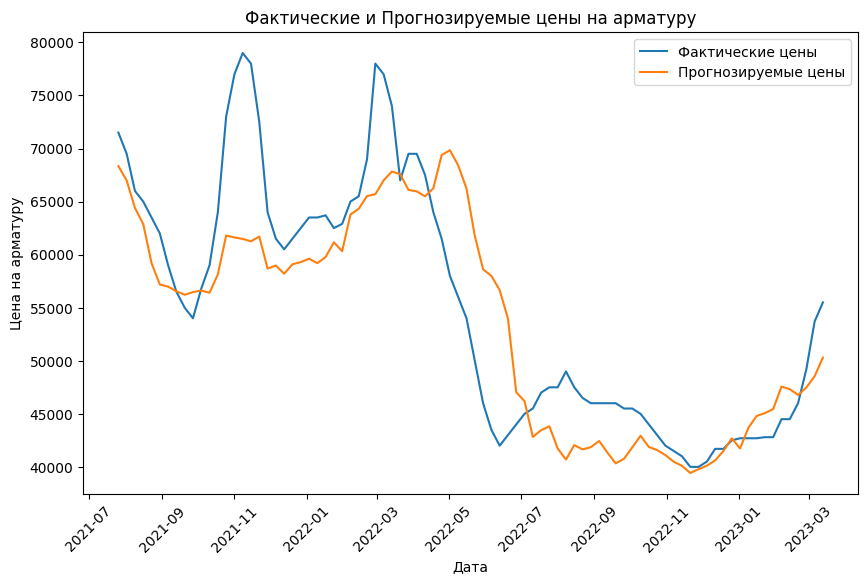

In [16]:
# Визуализация фактических и предсказанных цен
plt.figure(figsize=(10, 6))
plt.plot(df["Date"].iloc[-len(y_test):], y_test, label="Фактические цены")
plt.plot(df["Date"].iloc[-len(y_test):], predictions, label="Прогнозируемые цены")
plt.legend()
plt.xlabel("Дата")
plt.ylabel("Цена на арматуру")
plt.title("Фактические и Прогнозируемые цены на арматуру")
plt.xticks(rotation=45)
plt.show()

In [15]:
import pickle
with open('CatBoost_model.pkl', 'wb') as f: pickle.dump(model, f)

Для сравнения XGB

In [53]:
Xgb = X
Xgb['rolling_mean'] = y.rolling(window=3).mean()

In [54]:
Xgb_train, Xgb_test, ygb_train, ygb_test = train_test_split(Xgb, y, test_size=0.2, shuffle=False)

In [55]:
Xgb_train = Xgb_train.drop('Date', axis=1)
Xgb_test = Xgb_test.drop('Date', axis=1)

In [ ]:
# %pip install xgboost
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from math import sqrt

In [56]:
# Определяем модель
xgb_model = XGBRegressor()

# Подгоняем модель на данных
xgb_model.fit(Xgb_train, ygb_train)

# Прогнозируем на тестовых данных
ygb_pred = xgb_model.predict(Xgb_test)

# Оцениваем модель
mae = mean_absolute_error(ygb_test, ygb_pred)
r2 = r2_score(ygb_test, ygb_pred)
rmse = sqrt(mean_squared_error(ygb_test, ygb_pred))

print(f"MAE score: {mae}")
print(f"R2 score: {r2}")
print(f"RMSE score: {rmse}")

MAE score: 3179.237191133721
R2 score: 0.8485344037910103
RMSE score: 4454.9705441662745


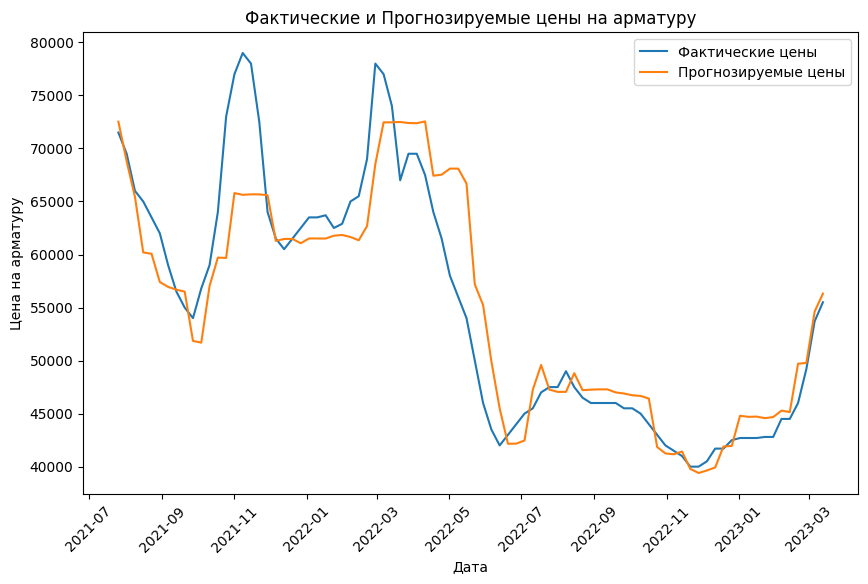

In [26]:
# Визуализация фактических и предсказанных цен
plt.figure(figsize=(10, 6))
plt.plot(df["Date"].iloc[-len(y_test):], y_test, label="Фактические цены")
plt.plot(df["Date"].iloc[-len(y_test):], ygb_pred, label="Прогнозируемые цены")
plt.legend()
plt.xlabel("Дата")
plt.ylabel("Цена на арматуру")
plt.title("Фактические и Прогнозируемые цены на арматуру")
plt.xticks(rotation=45)
plt.show()

In [21]:
import pickle
with open('XGBoost_model.pkl', 'wb') as f: pickle.dump(model, f)

Поиск параметров (не удачный)

In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

# Определяем модель
catboost_model = CatBoostRegressor(verbose=0)

# Определяем сетку параметров для поиска
param_grid = {
    'iterations': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5]
}

# Определяем метрику для оценки
scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# Создаем GridSearchCV объект
grid_search = GridSearchCV(estimator=catboost_model, param_grid=param_grid, scoring=scorer, cv=5)

# Подгоняем модель на данных
grid_search.fit(X_train, y_train)

# Выводим лучшие параметры
print("Лучшие параметры: ", grid_search.best_params_)

# Оцениваем модель на тестовых данных
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

Лучшие параметры:  {'depth': 4, 'iterations': 300, 'l2_leaf_reg': 5, 'learning_rate': 0.01}
